In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

#switch dir and load packages
import os

os.chdir(r'..\..')

from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs, compute_lcc, lcc_plot, recategorize_cost



Dit notebook geeft een voorbeeld hoe kosten kunnen worden bepaald uit output files van de Verkenning-2.0-backend
We gebruiken 3 kosteninschattingen van de Scheldestromen casus als voorbeeld.

## Invoerpaden en incrementele versterkingen
In onderstaande cel moet de werkmap met de kostenuitvoer worden geselecteerd, en de filenamen van de verschillende versterkingen. Daarbij kan per file een naam van de maatregel worden opgegeven waarmee later evt. kan worden gecombineerd tot adaptatiepad.

In [2]:
# Path of WJK
working_dir = Path(r"c:\Users\klerk_wj\Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")
# Path of Yida
# working_dir = Path(r"C:\Users\tao\OneDrive - Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")

sns.set_palette("husl", 12)



## Berekenen van kosten van incrementele versterkingen
Nu gaan we de kosten van incrementele versterkingen bepalen. Deze worden gebaseerd op de met de toolbox bepaalde kosten. 
We hebben dus kosten van bijv huidige situatie naar Grondversterking 2026 en huidige situatie naar Grondversterking 2075.
We gaan nu de kosten berekenen voor Grondversterking 2025 naar Grondversterking 2075, dus alleen de meerkosten.

## Adaptatiepad 1: grondversterking
We kijken eerst puur naar het adaptatiepad voor grondversterking.

In [3]:
## SETTINGS ## 
files = ['ontwerpvariant grond gestacked/kostenoverzicht design grond 1.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 2 aanlegprofiel.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',]

names = ["Grondversterking 2025", "Grondversterking 2075", "Grondversterking 2125"]

alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}:")
    print(f"€{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
print("Kosten van alle losse alternatieven:")
#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]

cost_per_increment_summary, cost_per_increment_detailed, dimensions_per_increment = compute_incremental_costs(names, dimensions, dike)

df_all_increments = pd.concat(cost_per_increment_summary.values(), axis=1)
df_all_increments.columns = cost_per_increment_summary.keys()
df_all_increments.columns = [col + " (incrementeel)" for col in df_all_increments.columns]


#merge the incremental costs with the plain costs
df_all_costs_with_increments = pd.concat([df_all_costs, df_all_increments], axis=1)
df_all_costs_with_increments
#add (incrementeel) to the column names of df_all_increments before merging

#add Vastgoedkosten 1300000 for Grondversterking 2025
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 (ruw)'] = 1300000
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2075 (ruw)'] = 1300000 + 100 * (250*3)
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2125 (ruw)'] = 1300000 + 100 * (250*3) + 100 * (250*5)

#add grondaankoop kosten for Grondversterking 2075 and 2125:
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 (incrementeel)'] = 1300000
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 to Grondversterking 2075 (incrementeel)'] = 100 * (250*3)
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2075 to Grondversterking 2125 (incrementeel)'] = 100 * (250*5)

print("Kosten per versterking (ruw en incrementeel):")
df_all_costs_with_increments


Kosten van beginsituatie naar Grondversterking 2025:
€1,317,010
Kosten van beginsituatie naar Grondversterking 2075:
€1,630,445
Kosten van beginsituatie naar Grondversterking 2125:
€2,125,449
Kosten van alle losse alternatieven:
Kosten van Grondversterking 2025:
€1,317,010


Incrementele kosten van Grondversterking 2025 naar Grondversterking 2075:
€1,400,548


Incrementele kosten van Grondversterking 2075 naar Grondversterking 2125:
€1,773,155


Kosten per versterking (ruw en incrementeel):


,Grondversterking 2025 (ruw),Grondversterking 2075 (ruw),Grondversterking 2125 (ruw),Grondversterking 2025 (incrementeel),Grondversterking 2025 to Grondversterking 2075 (incrementeel),Grondversterking 2075 to Grondversterking 2125 (incrementeel)
Directe kosten grondwerk,2.890552e+05,4.226210e+05,6.383002e+05,2.890552e+05,313398.468368,470927.830730
Directe kosten constructies,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
Directe kosten infrastructuur,2.900054e+05,3.032242e+05,3.200169e+05,2.900054e+05,303224.166200,320016.907870
Directe niet-benoemde bouwkosten,3.767220e+04,4.300105e+04,5.115070e+04,3.767220e+04,39724.370671,46129.525709
Indirecte bouwkosten,2.170939e+05,2.706388e+05,3.553391e+05,2.170939e+05,231038.346465,294655.498312
Engineeringkosten,1.869504e+05,2.330606e+05,3.060003e+05,1.869504e+05,198958.653566,253742.558787
Overige bijkomende kosten,7.515594e+04,9.369269e+04,1.230152e+05,7.515594e+04,79983.378318,102007.058809
Objectoverstijgende risicoreservering,2.210773e+05,2.642069e+05,3.316270e+05,2.210773e+05,234220.272050,285675.545256
Vastgoedkosten,1.300000e+06,1.375000e+06,1.500000e+06,1.300000e+06,75000.000000,125000.000000


In [4]:
df_all_costs_with_increments = recategorize_cost(df_all_costs_with_increments)
df_all_costs_with_increments

,Grondversterking 2025 (ruw),Grondversterking 2075 (ruw),Grondversterking 2125 (ruw),Grondversterking 2025 (incrementeel),Grondversterking 2025 to Grondversterking 2075 (incrementeel),Grondversterking 2075 to Grondversterking 2125 (incrementeel)
Directe bouwkosten (grondwerk),2.890552e+05,4.226210e+05,6.383002e+05,2.890552e+05,313398.468368,470927.830730
Directe bouwkosten (constructies),0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
Directe bouwkosten (infrastructuur),2.900054e+05,3.032242e+05,3.200169e+05,2.900054e+05,303224.166200,320016.907870
Directe bouwkosten (niet-benoemd),3.767220e+04,4.300105e+04,5.115070e+04,3.767220e+04,39724.370671,46129.525709
"Indirecte en bijkomende kosten (engineering, risico e.d.)",7.002775e+05,8.615989e+05,1.115982e+06,7.002775e+05,744200.650399,936080.661163
Vastgoedkosten,1.300000e+06,1.375000e+06,1.500000e+06,1.300000e+06,75000.000000,125000.000000


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\136574086.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


[Text(0, 0, 'Grondversterking 2025'),
 Text(1, 0, 'Grondversterking 2075'),
 Text(2, 0, 'Grondversterking 2125')]

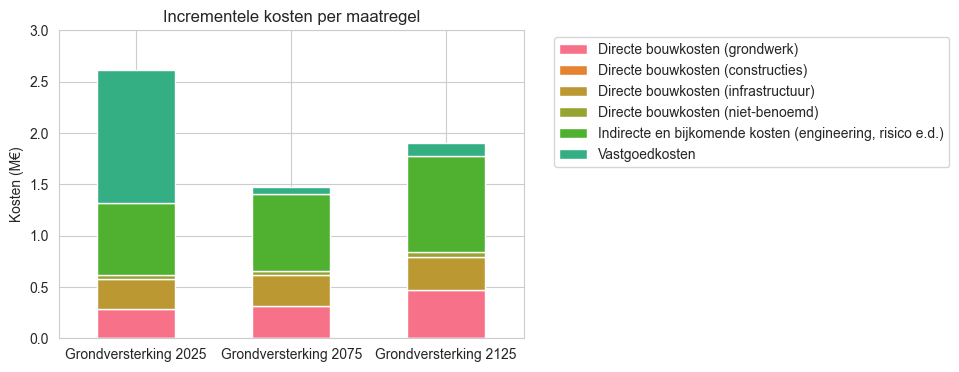

In [5]:
#make a stacked bar plot of all the increment costs per measure
fig, ax = plt.subplots(figsize=(6,4))
increment_costs_only = df_all_costs_with_increments.loc[:, [col for col in df_all_costs_with_increments.columns if '(incrementeel)' in col]]
increment_costs_only.T.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Incrementele kosten per maatregel')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(ax.get_ylim()[1] / 1e6)*1e6)
#make legend outside of the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')


#scale y-axislabels to millions
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])

#rotate x-axis labels and remove (incrementeel) and everything before "to"from the labels
ax.set_xticklabels([label.get_text().split(' to ')[-1].replace(' (incrementeel)', '') for label in ax.get_xticklabels()], rotation=0, ha='center')
# ax.set_ylim(0, ax.get_ylim()[1] / 1e6)


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\2901974345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


[Text(0, 0, 'Grondversterking 2025'),
 Text(1, 0, 'Grondversterking 2075'),
 Text(2, 0, 'Grondversterking 2125')]

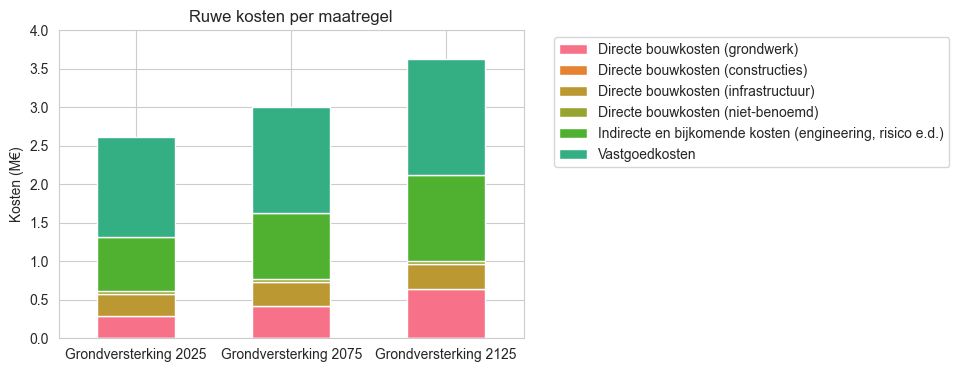

In [6]:
#same plot for (ruw) costs
fig, ax = plt.subplots(figsize=(6,4))
raw_costs_only = df_all_costs_with_increments.loc[:, [col for col in df_all_costs_with_increments.columns if '(ruw)' in col]]
raw_costs_only.T.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Ruwe kosten per maatregel')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(ax.get_ylim()[1] / 1e6)*1e6)
#make legend outside of the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

#scale y-axislabels to millions
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
#rotate x-axis labels and remove (ruw) and everything before "to" from the labels
ax.set_xticklabels([label.get_text().split(' to ')[-1].replace(' (ruw)', '') for label in ax.get_xticklabels()], rotation=0, ha='center')


c:\Repositories\Verkenning-2.0-backend\dev\incremental_costs\utils.py:317: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


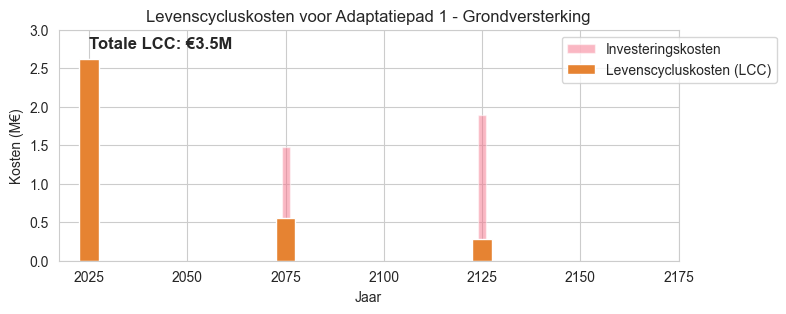

In [7]:
#LCC computation
#make dict with sum of incremental costs per measure, year, lifespan (50 for soil) in a tuple
incremental_costs_per_measure = {}
for col in increment_costs_only.columns:
    measure_name = col.split(' (incrementeel)')[0]
    #find the year in the measure name 
    year = int(measure_name.split(' ')[-1])
    incremental_costs_per_measure[measure_name] = (increment_costs_only[col].sum(), year, 100)
    # incremental_costs_per_measure[measure_name] = (increment_costs_only[col].sum(), year, 50)

total_horizon = 150
lcc_per_measure = compute_lcc(incremental_costs_per_measure, total_horizon=total_horizon)
lcc_per_measure

undiscounted_costs_adaptation_path_1 = [cost for cost, year, lifespan in incremental_costs_per_measure.values()]
lcc_values_adaptation_path_1 = [lcc for lcc in lcc_per_measure.values()]
years_adaptation_path_1 = [year for cost, year, lifespan in incremental_costs_per_measure.values()]



lcc_plot(undiscounted_costs_adaptation_path_1, lcc_values_adaptation_path_1, years_adaptation_path_1, total_horizon, title='Levenscycluskosten voor Adaptatiepad 1 - Grondversterking')

## Adaptatiepad 2 - constructief

Maatregelen, en welk grondprofiel er bij hoort:
2025:
* Verankerde damwand 2025

2075:
* 2a: Oplassen & ophoging kruin + taludverflauwing 2075
* 2b: Ophogen kruin + taludverflauwing + plaatsen L-wanden 2075
* nvt, geen grond: L-wand/keermuur op kruin

2125:
* 3a: Ophogen kruin + oplassen + buispalen bijplaatsen 2125
* 3b: Ophogen kruin + plaatsen L-wand
* 2d: Ophogen kruin, kistdam in binnenteen
* 2d: Ophogen kruin + kistdam in kruin + afschrijven damwand
* grond 2125: Binnenwaarts in grond, damwand afschrijven


In [8]:
## SETTINGS ## 
files = ['ontwerpvarianten constructief/kostenoverzicht_damwand15m_verankerd.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2a.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2b.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht_damwand15m_verankerd.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3a.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 3b.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2d.xlsx',
         'ontwerpvarianten constructief/kostenoverzicht 2d.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',
         ]

names = ["Verankerde damwand 2025",
         "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075",
         "Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075",
         "L-wand op kruin 2075",
         "Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125",
         "Ophogen kruin + Plaatsen L-wanden 2125",
         "Ophogen kruin + Kistdam in binnenteen 2125",
         "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125",
         "Grondversterking 2125",
         ]

#  unit prices for custom structures #TODO check and align values:
unit_prices = {'oplassen variabel per meter damwand per strekkende meter': 200, #o.b.v. prijzen korte damwand (licht profiel, dat is mogelijk optimistisch)
               'oplassen vaste kosten per strekkende meter': 200, #o.b.v. unit price stalen gording
               'L-wand 1.5 meter hoog per strekkende meter': 200, #o.b.v. kosten bij agri-beton.nl (keerwand 150x200x78)
               'Buispalen bijplaatsen per strekkende meter': (7000 / 2.8),  # EU/st / h.o.h. 7000 per buispaal, 2.8m per buispaal
               'Kistdam in binnenteen per strekkende meter':6000, # nog checken, grofweg directe kosten van bestaande verankerde damwand
               'Kistdam in kruin per strekkende meter': 12000, #nog checken, 2x kosten van damwand in de teen. Lengte is mogelijk langer, maar ankers zijn dan weer goedkoper.
               'Afbranden bestaande damwand per strekkende meter': 200,  #nog checken,
                }

 
alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

vaklengte = dimensions['Verankerde damwand 2025']['structure']['Vaklengte'].copy()
#update costs to include the custom structure costs.
for name, dimension in dimensions.items():
    if name == "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075":
        lengte_oplassen = 3.5 #m, aannemend dat er 1 vak van 3.5m nodig is om de kruin te versterken, dit is mogelijk optimistisch
        dimension['structure'] = {'Type': f'Oplassen damwand {lengte_oplassen} meter', 
                                  'Vaklengte': vaklengte, 
                                  'Eenheidsprijs': unit_prices['oplassen variabel per meter damwand per strekkende meter'] * lengte_oplassen + unit_prices['oplassen vaste kosten per strekkende meter']}
    elif name == "Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075":
        aantal_wanden = 2
        dimension['structure'] = {'Type': f'Plaatsen {aantal_wanden} L-wanden bij teen', 
                                  'Vaklengte': vaklengte, 
                                  'Eenheidsprijs': unit_prices['L-wand 1.5 meter hoog per strekkende meter'] * aantal_wanden}
        pass
    elif name == "L-wand op kruin 2075":
        dimension['structure'] = {'Type': f'L-wand 1.5 meter hoog op kruin', 
                                  'Vaklengte': vaklengte,
                                    'Eenheidsprijs': unit_prices['L-wand 1.5 meter hoog per strekkende meter']}
    elif name == "Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125":
        lengte_oplassen = 1.8
        dimension['structure'] = {'Type': f'Oplassen damwand {lengte_oplassen} meter + Buispalen bijplaatsen',
                                    'Vaklengte': vaklengte,
                                    'Eenheidsprijs': unit_prices['oplassen variabel per meter damwand per strekkende meter'] * lengte_oplassen + unit_prices['oplassen vaste kosten per strekkende meter'] + unit_prices['Buispalen bijplaatsen per strekkende meter']}
    elif name == "Ophogen kruin + Plaatsen L-wanden 2125":
        aantal_wanden = 5
        dimension['structure'] = {'Type': f'Plaatsen {aantal_wanden} L-wanden bij teen',
                                    'Vaklengte': vaklengte,
                                    'Eenheidsprijs': unit_prices['L-wand 1.5 meter hoog per strekkende meter'] * aantal_wanden}
    elif name == "Ophogen kruin + Kistdam in binnenteen 2125":
        dimension['structure'] = {'Type': f'Kistdam in binnenteen',
                                    'Vaklengte': vaklengte,
                                    'Eenheidsprijs': unit_prices['Kistdam in binnenteen per strekkende meter']}
    elif name == "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125":
        dimension['structure'] = {'Type': f'Kistdam in kruin + Afschrijven damwand',
                                    'Vaklengte': vaklengte,
                                    'Eenheidsprijs': unit_prices['Kistdam in kruin per strekkende meter'] + unit_prices['Afbranden bestaande damwand per strekkende meter']}
    elif name == "Grondversterking 2125":
        dimension['structure'] = {'Type': f'Afbranden bestaande damwand',
                                    'Vaklengte': vaklengte,
                                    'Eenheidsprijs': unit_prices['Afbranden bestaande damwand per strekkende meter']}
    else:
        pass

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}: €{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]

df_all_costs.loc['Vastgoedkosten', 'Grondversterking 2125 (ruw)'] = 1300000 + 100 * (250*3) + 100 * (250*5)




Kosten van beginsituatie naar Verankerde damwand 2025: €4,809,912
Kosten van beginsituatie naar Ophogen kruin + Taludverflauwing + Oplassen damwand 2075: €1,245,939
Kosten van beginsituatie naar Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075: €1,144,113
Kosten van beginsituatie naar L-wand op kruin 2075: €561,271
Kosten van beginsituatie naar Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125: €2,957,006
Kosten van beginsituatie naar Ophogen kruin + Plaatsen L-wanden 2125: €1,697,940
Kosten van beginsituatie naar Ophogen kruin + Kistdam in binnenteen 2125: €4,852,720
Kosten van beginsituatie naar Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125: €9,191,081
Kosten van beginsituatie naar Grondversterking 2125: €2,265,397


In [9]:
df_all_costs

,Verankerde damwand 2025 (ruw),Ophogen kruin + Taludverflauwing + Oplassen damwand 2075 (ruw),Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075 (ruw),L-wand op kruin 2075 (ruw),Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125 (ruw),Ophogen kruin + Plaatsen L-wanden 2125 (ruw),Ophogen kruin + Kistdam in binnenteen 2125 (ruw),Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125 (ruw),Grondversterking 2125 (ruw)
Directe kosten grondwerk,0.000000e+00,202096.075973,241804.817589,0.000000,296921.699657,305758.630826,1.436892e+05,1.436892e+05,6.383002e+05
Directe kosten constructies,1.796119e+06,257742.977247,114552.434332,57276.217166,876326.122641,286381.085831,1.718287e+06,3.493849e+06,5.727622e+04
Directe kosten infrastructuur,1.724355e+05,78086.516271,145395.248342,172435.525262,78104.253427,145138.323682,1.440066e+05,1.440066e+05,3.200169e+05
Directe niet-benoemde bouwkosten,1.968554e+05,39645.831631,33248.912795,22971.174243,104350.688597,52324.699876,1.905400e+05,3.680963e+05,5.687832e+04
Indirecte bouwkosten,7.622381e+05,203308.829652,188323.921406,88946.003839,477216.049539,277945.218013,7.731899e+05,1.460700e+06,3.775169e+05
Engineeringkosten,6.564013e+05,175079.382382,162175.129845,76595.844087,410954.562864,239352.502245,6.658324e+05,1.257882e+06,3.250986e+05
Overige bijkomende kosten,2.638799e+05,70383.671309,65196.032099,30792.299130,165207.864468,96222.111455,2.676713e+05,5.056812e+05,1.306929e+05
Objectoverstijgende risicoreservering,9.619823e+05,219596.013711,193416.393766,112254.265932,547924.492687,294817.394748,9.495044e+05,1.817177e+06,3.596164e+05
Vastgoedkosten,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.500000e+06


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\3666928458.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


[Text(0, 0, 'Verankerde damwand 2025'),
 Text(1, 0, 'Ophogen kruin + Taludverflauwing + Oplassen damwand 2075'),
 Text(2, 0, 'Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075'),
 Text(3, 0, 'L-wand op kruin 2075'),
 Text(4, 0, 'Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125'),
 Text(5, 0, 'Ophogen kruin + Plaatsen L-wanden 2125'),
 Text(6, 0, 'Ophogen kruin + Kistdam in binnenteen 2125'),
 Text(7, 0, 'Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125'),
 Text(8, 0, 'Grondversterking 2125')]

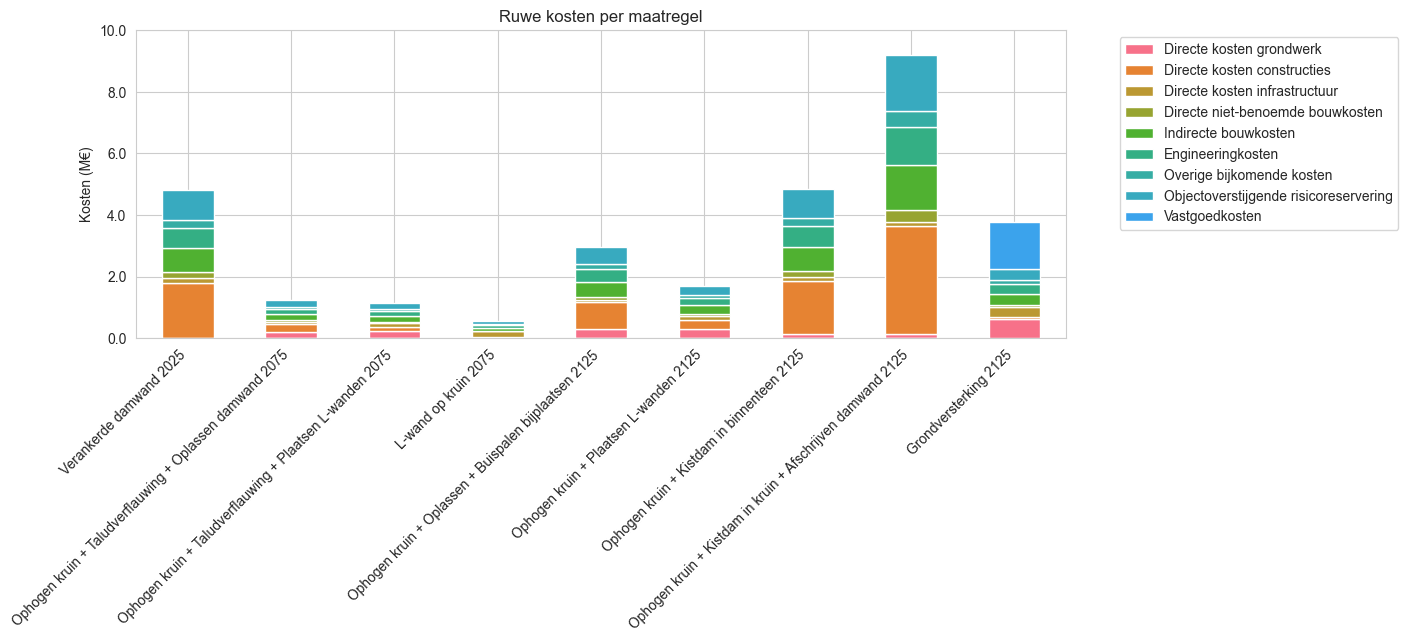

In [10]:
#same plot for (ruw) costs
fig, ax = plt.subplots(figsize=(12,4))
df_all_costs.T.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Ruwe kosten per maatregel')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(ax.get_ylim()[1] / 1e6)*1e6)
#make legend outside of the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

#scale y-axislabels to millions
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
#rotate x-axis labels and remove (ruw) and everything before "to" from the labels
ax.set_xticklabels([label.get_text().split(' to ')[-1].replace(' (ruw)', '') for label in ax.get_xticklabels()], rotation=45, ha='right')

### Adaptatiepad 2: constructief

In [11]:
measure_orders = {"Adaptatiepad 2a - damwand met oplassen": ["Verankerde damwand 2025", "Ophogen kruin + Taludverflauwing + Oplassen damwand 2075", "Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125",],
                  "Adaptatiepad 2b - damwand met L-wanden": ["Verankerde damwand 2025", "Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075", "Ophogen kruin + Plaatsen L-wanden 2125",],
                  "Adaptatiepad 2c - damwand met kruinmuur & kistdam in teen": ["Verankerde damwand 2025", "L-wand op kruin 2075", "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125",],
                  "Adaptatiepad 2d - damwand met kruinmuur & kistdam in kruin": ["Verankerde damwand 2025", "L-wand op kruin 2075", "Ophogen kruin + Kistdam in kruin + Afschrijven damwand 2125",],
                  "Adaptatiepad 2e - damwand met kruinmuur & grondversterking": ["Verankerde damwand 2025", "L-wand op kruin 2075", "Grondversterking 2125",],
                  }

adaptation_paths_summary, adaptation_paths_detailed, adaptation_paths_dimensions = {}, {}, {}
#compute incremental costs for the different measure orders
for adaptation_path, measure_order in measure_orders.items():
    adaptation_paths_summary[adaptation_path], adaptation_paths_detailed[adaptation_path], adaptation_paths_dimensions[adaptation_path] = compute_incremental_costs(measure_order, dimensions, dike)
    summary, adaptation_paths_detailed[adaptation_path], adaptation_paths_dimensions[adaptation_path] = compute_incremental_costs(measure_order, dimensions, dike)

    adaptation_paths_summary[adaptation_path] = pd.concat(summary.values(), axis=1)
    adaptation_paths_summary[adaptation_path].columns = summary.keys()

    if 'Grondversterking 2125' in measure_order:
        #add Vastgoedkosten for measure that contains "to Grondversterking 2125"
        adaptation_paths_summary[adaptation_path].loc['Vastgoedkosten', 
                                                      adaptation_paths_summary[adaptation_path].columns[adaptation_paths_summary[adaptation_path].columns.str.contains('to Grondversterking 2125')]] = 1300000 + 100 * (250*5)


Kosten van Verankerde damwand 2025:
€4,809,912


Incrementele kosten van Verankerde damwand 2025 naar Ophogen kruin + Taludverflauwing + Oplassen damwand 2075:
€1,169,847


Incrementele kosten van Ophogen kruin + Taludverflauwing + Oplassen damwand 2075 naar Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125:
€2,799,413


Kosten van Verankerde damwand 2025:
€4,809,912


Incrementele kosten van Verankerde damwand 2025 naar Ophogen kruin + Taludverflauwing + Oplassen damwand 2075:
€1,169,847


Incrementele kosten van Ophogen kruin + Taludverflauwing + Oplassen damwand 2075 naar Ophogen kruin + Oplassen + Buispalen bijplaatsen 2125:
€2,799,413


Kosten van Verankerde damwand 2025:
€4,809,912


Incrementele kosten van Verankerde damwand 2025 naar Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075:
€1,056,268


Incrementele kosten van Ophogen kruin + Taludverflauwing + Plaatsen L-wanden 2075 naar Ophogen kruin + Plaatsen L-wanden 2125:
€1,497,783


Kosten van Verankerde damwand 20

Text(0.5, 0.98, 'Incrementele kosten per adaptatiepad voor constructieve maatregelen')

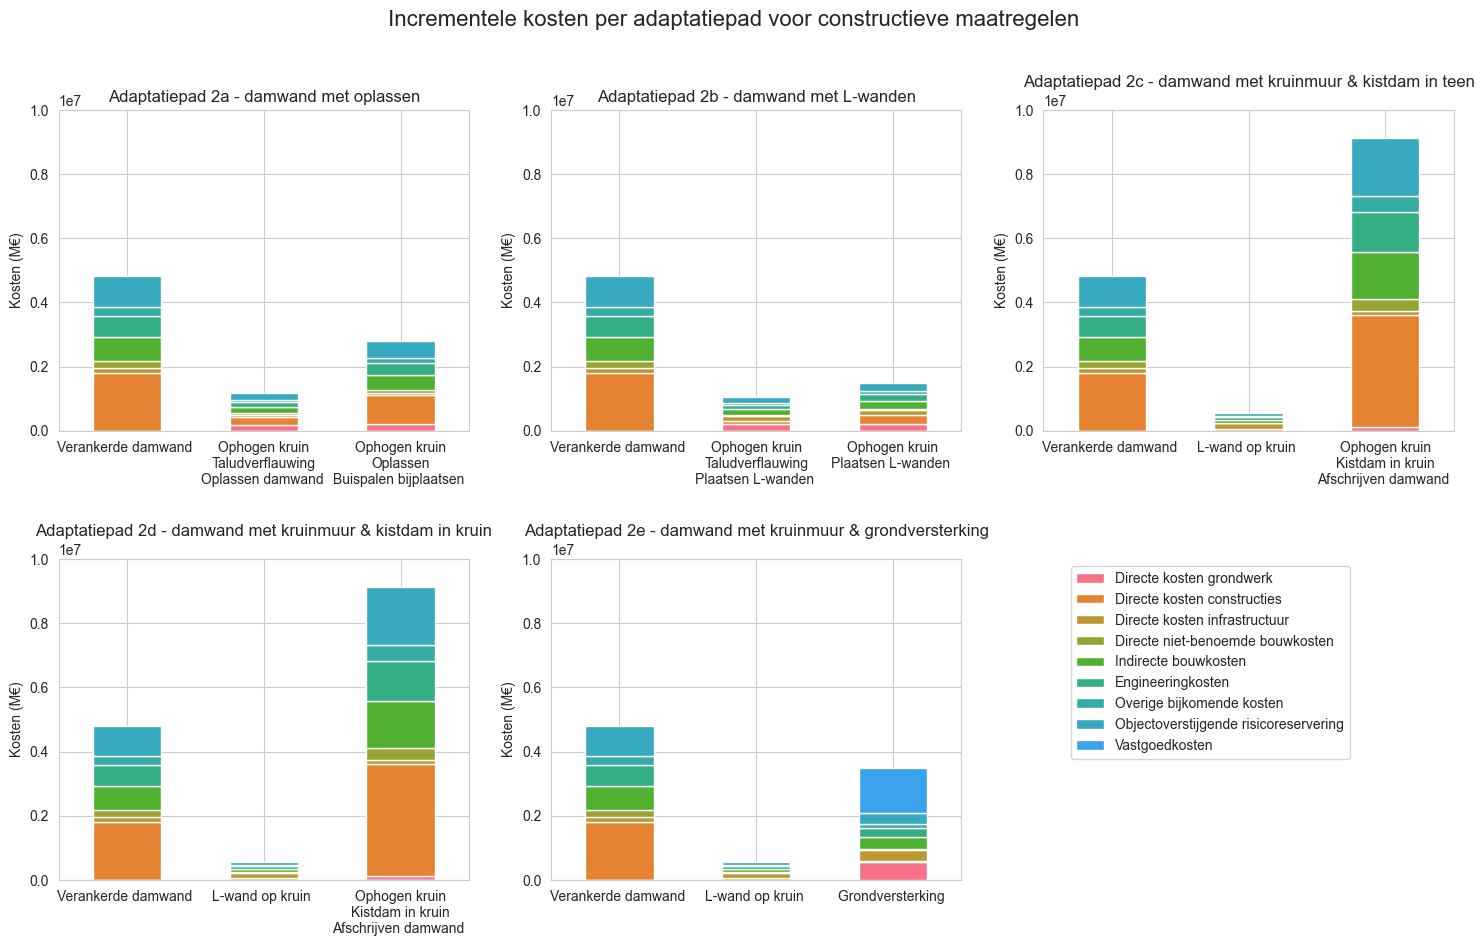

In [12]:
#make a stacked bar plot of all the increment costs per adaptation path. We have 5 paths, so make 6 subplots (2x3), one for each path and one where we can put the legend
# 

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, (adaptation_path, summary) in enumerate(adaptation_paths_summary.items()):
    summary.T.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(adaptation_path)
    #no legend
    axes[i].legend_.remove()
    axes[i].set_ylabel('Kosten (M€)')
    axes[i].set_ylim(0, 1e7)
    #rotate the labels and split along multiple lines if they are too long (max length per line is 15 characters. Split at ' to ' and + if possible, otherwise split at the max length of 15 characters per line)
    #rotate x-axis labels and remove (incrementeel) and everything before "to"from the labels. Replace all " + " with "\n" for better readability. Remove 2025, 2075 and 2125 from the labels for better readability.
    axes[i].set_xticklabels([label.get_text().split(' to ')[-1].replace(' + ', '\n').replace('2025', '').replace('2075', '').replace('2125', '') for label in axes[i].get_xticklabels()], rotation=0, ha='center')
    # #add horizontal padding between subplots
plt.subplots_adjust(hspace=.4)

#make space of 6th plot entirely white
axes[5].axis('off')
handles, labels = axes[4].get_legend_handles_labels()
axes[4].legend(handles, labels, bbox_to_anchor=(1.25, 1), loc='upper left')

fig.suptitle('Incrementele kosten per adaptatiepad voor constructieve maatregelen', fontsize=16)


c:\Repositories\Verkenning-2.0-backend\dev\incremental_costs\utils.py:317: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
c:\Repositories\Verkenning-2.0-backend\dev\incremental_costs\utils.py:317: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
c:\Repositories\Verkenning-2.0-backend\dev\incremental_costs\utils.py:317: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
c:\Repositories\Verkenning-2.0-backend\dev\incremental_costs\utils.py:317: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

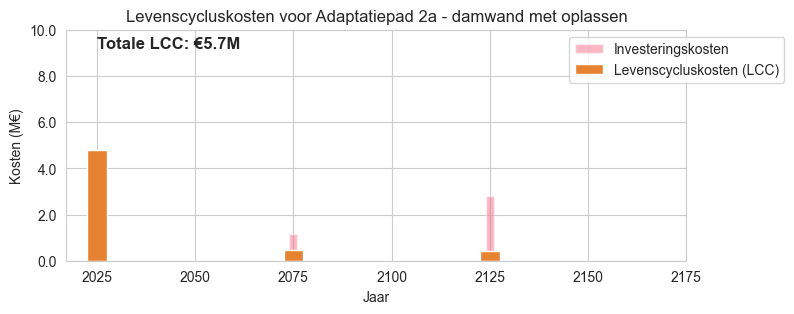

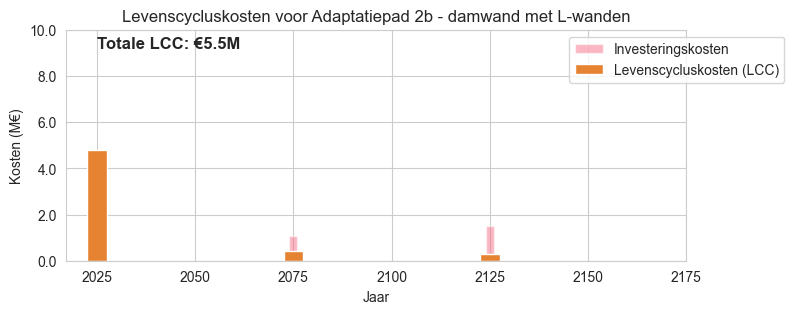

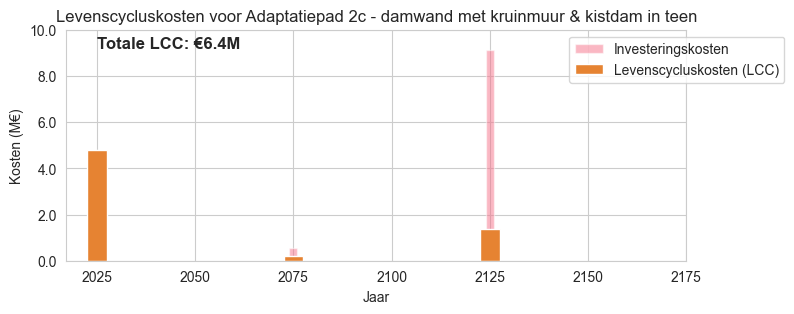

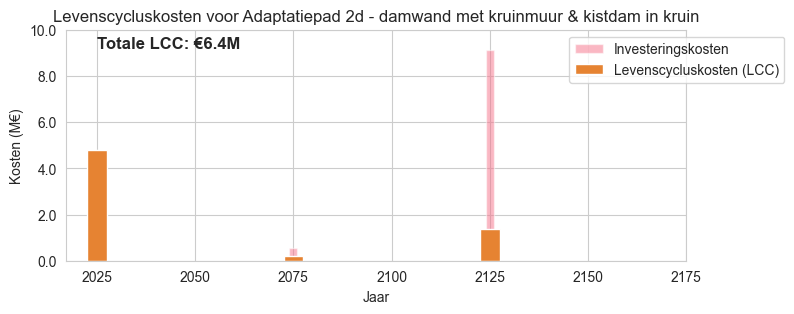

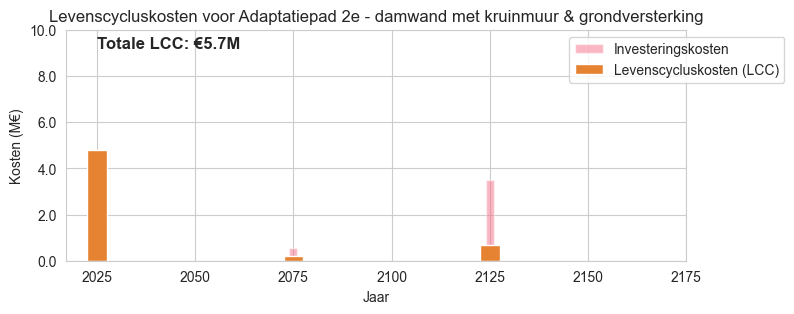

In [13]:
#LCC computation for each adaptation path
#make dict with sum of incremental costs per measure, year, lifespan (50 for soil) in a tuple
adaptation_paths_lcc = {}
adaptation_paths_investment = {}
adaptation_paths_years = {}
for adaptation_path, summary in adaptation_paths_summary.items():
    incremental_costs_per_measure = {}
    for increment_name in summary.columns:
        #find the year in the measure name
        measure_name = increment_name.split(' to ')[-1]
        year = int(measure_name.split(' ')[-1])
        if 'Verankerde damwand' in measure_name or 'Kistdam' in measure_name or 'Buispalen' in measure_name:
            incremental_costs_per_measure[measure_name] = (summary[increment_name].sum(), year, 100)
        else:
            incremental_costs_per_measure[measure_name] = (summary[increment_name].sum(), year, 50)

    total_horizon = 150
    adaptation_paths_lcc[adaptation_path] = compute_lcc(incremental_costs_per_measure, total_horizon=total_horizon)
    adaptation_paths_investment[adaptation_path] = [cost for cost, year, lifespan in incremental_costs_per_measure.values()]
    adaptation_paths_years[adaptation_path] = [year for cost, year, lifespan in incremental_costs_per_measure.values()]

    
    lcc_plot(adaptation_paths_investment[adaptation_path], adaptation_paths_lcc[adaptation_path].values(), adaptation_paths_years[adaptation_path], total_horizon, title=f'Levenscycluskosten voor {adaptation_path}', y_top_lim = 10e6)

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\2232203667.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\2232203667.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\2232203667.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_18980\2232203667.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set

[Text(0, 0, 'Adaptatiepad 1 - grondversterking'),
 Text(1, 0, 'Adaptatiepad 2a - damwand met oplassen'),
 Text(2, 0, 'Adaptatiepad 2b - damwand met L-wanden'),
 Text(3, 0, 'Adaptatiepad 2c - damwand met kruinmuur & kistdam in teen'),
 Text(4, 0, 'Adaptatiepad 2d - damwand met kruinmuur & kistdam in kruin'),
 Text(5, 0, 'Adaptatiepad 2e - damwand met kruinmuur & grondversterking')]

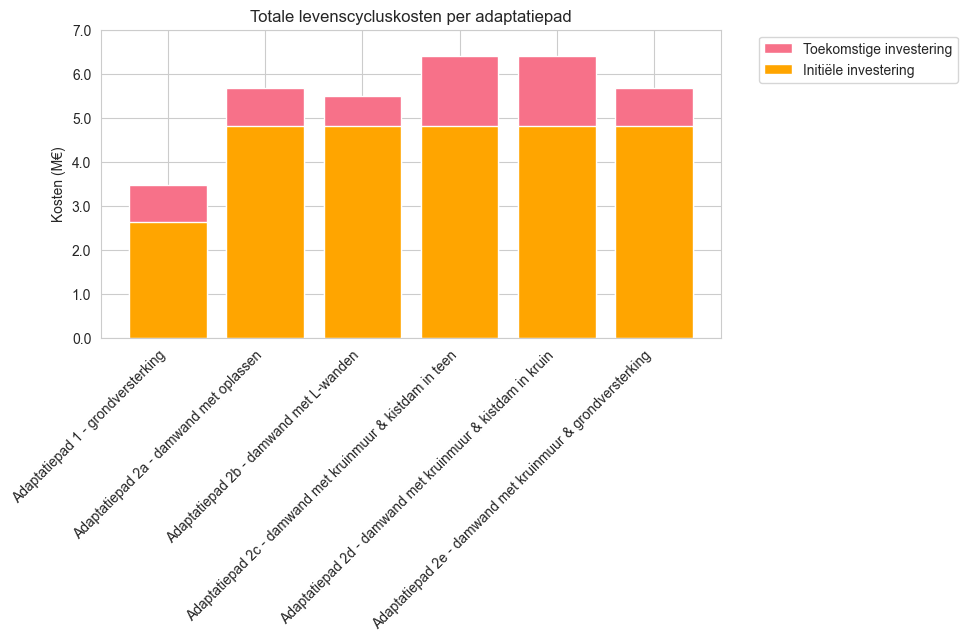

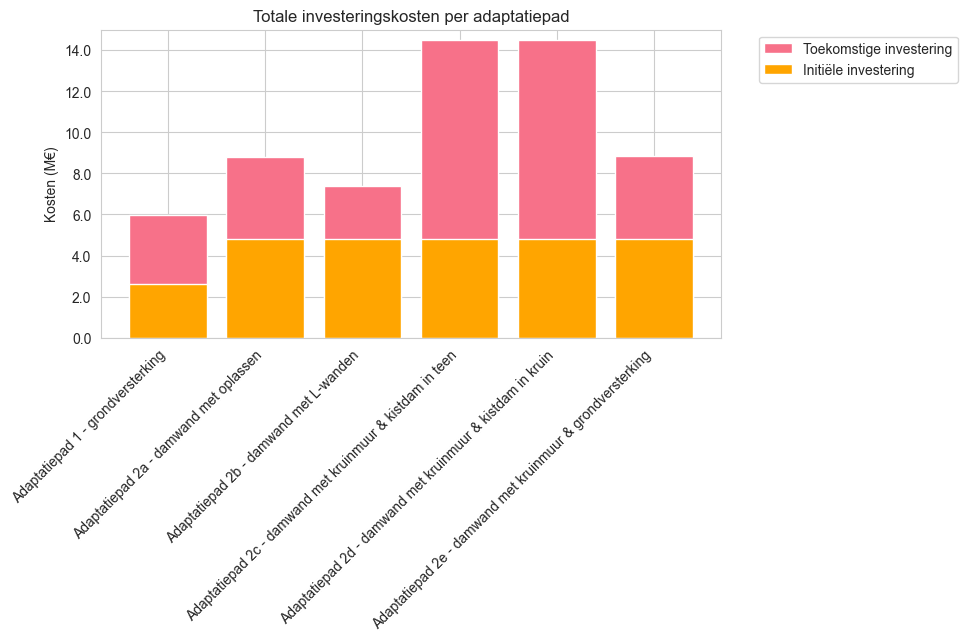

In [14]:
#for all adaptation paths get the total LCC
initial_investment_dict = {'Adaptatiepad 1 - grondversterking': lcc_per_measure['Grondversterking 2025']}
lcc_dict = {'Adaptatiepad 1 - grondversterking': sum(lcc_values_adaptation_path_1)}
total_investment_dict = {'Adaptatiepad 1 - grondversterking': sum(undiscounted_costs_adaptation_path_1)}


for adaptation_path, lcc_values in adaptation_paths_lcc.items():
    lcc_dict[adaptation_path] = sum(lcc_values.values())
    initial_investment_dict[adaptation_path] = adaptation_paths_investment[adaptation_path][0]
    total_investment_dict[adaptation_path] = sum(adaptation_paths_investment[adaptation_path])

#bar chart of total LCC per adaptation path
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(lcc_dict.keys(), lcc_dict.values(), label = 'Toekomstige investering')
ax.bar(initial_investment_dict.keys(), initial_investment_dict.values(), color='orange', label='Initiële investering')
ax.set_title('Totale levenscycluskosten per adaptatiepad')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(max(lcc_dict.values()) / 1e6)*1e6)
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

#bar chart of total investment per adaptation path
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(total_investment_dict.keys(), total_investment_dict.values(), label = 'Toekomstige investering')
ax.bar(initial_investment_dict.keys(), initial_investment_dict.values(), color='orange', label='Initiële investering')
ax.set_title('Totale investeringskosten per adaptatiepad')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(max(total_investment_dict.values()) / 1e6)*1e6)
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
